# Combined Overview of PMMA Measurements

_This notebook explores nano-FTIR measurements of PMMA deposited on Pt/SiO₂, examining spectral quality, SNR behavior, and contrast effects based on scan resolution and acquisition parameters._

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.fftpack import fft, fftfreq, ifft
from scipy.optimize import curve_fit


In [2]:
def einlesen(textdatei):
    df = pd.read_csv(textdatei, sep = '\t', skiprows = 29, header = 0, engine= 'python')
    data = df[['Wavenumber', 'O2A', 'O2P','Omega']].to_numpy()
    #A= df['02A']
    #P= df['02p']
    return data

In [3]:
data=einlesen('2020-06-23 192624 NF S Deep3_PMMA_on_Pt_BK_121mA_PMMA.txt')
#print(einlesen('2020-06-23 192624 NF S Deep3_PMMA_on_Pt_BK_121mA_PMMA.txt'))

n=0
P1 = np.zeros(1199) 
A1= np.zeros(1199)
W1=np.zeros(1199)
for i in range (n,n+1199):
    P1[i-n]= data[i,2]
    A1[i-n]= data[i,1]
    W1[i-n]= data [i,0]
    
data=einlesen('2020-06-23 193614 NF S Deep3_PMMA_on_Pt_BK_121mA_PMMA.txt')
#print(einlesen('2020-06-23 193902 NF S Deep3_PMMA_on_Pt_BK_115mA_PMMA.txt'))

n=0
P2 = np.zeros(1199) 
A2= np.zeros(1199)
W2=np.zeros(1199)
for i in range (n,n+1199):
    P2 [i-n]= data[i,2]
    A2[i-n]= data[i,1]
    W2[i-n]= data [i,0]
    
data=einlesen('2020-06-23 193902 NF S Deep3_PMMA_on_Pt_BK_115mA_PMMA.txt')
#print(einlesen('2020-06-23 193902 NF S Deep3_PMMA_on_Pt_BK_115mA_PMMA.txt'))

n=0
P3 = np.zeros(1199) 
A3= np.zeros(1199)
W3=np.zeros(1199)
for i in range (n,n+1199):
    P3 [i-n]= data[i,2]
    A3[i-n]= data[i,1]
    W3[i-n]= data [i,0]

data=einlesen('2020-06-23 194103 NF S Deep3_PMMA_on_Pt_BK_115mA_PMMA.txt')
#print(einlesen('2020-06-23 194103 NF S Deep3_PMMA_on_Pt_BK_115mA_PMMA.txt'))

n=0
P4 = np.zeros(1199) 
A4= np.zeros(1199)
W4=np.zeros(1199)
for i in range (n,n+1199):
    P4 [i-n]= data[i,2]
    A4[i-n]= data[i,1]
    W4[i-n]= data [i,0] 
    
data=einlesen('2020-06-23 174954 NF S Deep3_PMMA_on_Pt_BK_152mA.txt')
#print(einlesen('2020-06-23 174954 NF S Deep3_PMMA_on_Pt_BK_152mA.txt'))

n=0
P5 = np.zeros((1199, 1)) 
A5= np.zeros((1199, 1))
W5=np.zeros((1199, 1))
for i in range (n,n+1199):
    P5 [i-n]= data[i,2]
    A5[i-n]= data[i,1]
    W5[i-n]= data [i,0]
    
data=einlesen('2020-06-23 183810 NF S Deep3_PMMA_on_Pt_BK_132mA_PMMA.txt')
#print(einlesen('2020-06-23 183810 NF S Deep3_PMMA_on_Pt_BK_132mA_PMMA.txt'))

n=0
P6= np.zeros((1199, 1)) 
A6= np.zeros((1199, 1))
W6=np.zeros((1199, 1))
for i in range (n,n+1199):
    P6[i-n]= data[i,2]
    A6[i-n]= data[i,1]
    W6[i-n]= data [i,0]

data=einlesen('2020-06-23 191848 NF S Deep3_PMMA_on_Pt_BK_121mA_PMMA.txt')
#print(einlesen('2020-06-23 183810 NF S Deep3_PMMA_on_Pt_BK_132mA_PMMA.txt'))

n=0
P7= np.zeros((1199, 1)) 
A7= np.zeros((1199, 1))
W7=np.zeros((1199, 1))
for i in range (n,n+1199):
    P7 [i-n]= data[i,2]
    A7[i-n]= data[i,1]
    W7[i-n]= data [i,0]

<Figure size 432x288 with 0 Axes>

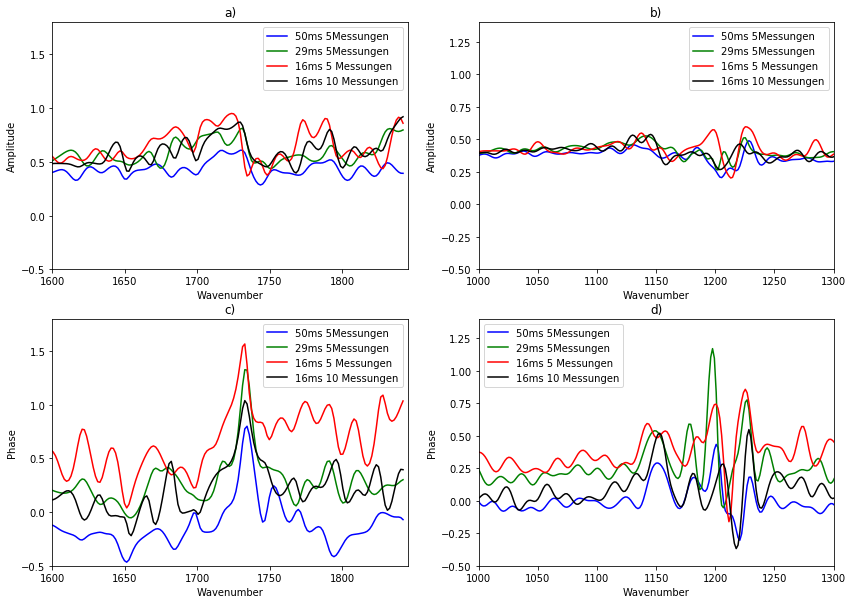

In [4]:
%matplotlib inline
plt.subplots_adjust(wspace=0.5,hspace=0.5)

plt.figure(figsize=(14,10)) 

plt.subplot(221) 
plt.plot(W1, A1, 'b-', label='50ms 5Messungen')
plt.plot(W2, A2, 'g-', label='29ms 5Messungen')
plt.plot(W3, A3, 'r-', label='16ms 5 Messungen')
plt.plot(W4, A4, 'k-', label='16ms 10 Messungen')
plt.title('a)')
plt.axis([1600, 1845, -0.5, 1.8])
plt.legend()
plt.xlabel('Wavenumber')
plt.ylabel('Amplitude')

plt.subplot(222)
plt.plot(W1, A1, 'b-', label='50ms 5Messungen')
plt.plot(W2, A2, 'g-', label='29ms 5Messungen')
plt.plot(W3, A3, 'r-', label='16ms 5 Messungen')
plt.plot(W4, A4, 'k-', label='16ms 10 Messungen')
plt.title('b)')
plt.axis([1000, 1300, -0.5, 1.4])
plt.legend()
plt.xlabel('Wavenumber')
plt.ylabel('Amplitude')

plt.subplot(223) 
plt.plot(W1, P1, 'b-', label='50ms 5Messungen')
plt.plot(W2, P2, 'g-', label='29ms 5Messungen')
plt.plot(W3, P3, 'r-', label='16ms 5 Messungen')
plt.plot(W4, P4, 'k-', label='16ms 10 Messungen')
plt.title('c)')
plt.axis([1600, 1845, -0.5, 1.8])
plt.legend()
plt.xlabel('Wavenumber')
plt.ylabel('Phase')

plt.subplot(224)
plt.plot(W1, P1, 'b-', label='50ms 5Messungen')
plt.plot(W2, P2, 'g-', label='29ms 5Messungen')
plt.plot(W3, P3, 'r-', label='16ms 5 Messungen')
plt.plot(W4, P4, 'k-', label='16ms 10 Messungen')
plt.title('d)')
plt.axis([1000, 1300, -0.5, 1.4])
plt.legend()
plt.xlabel('Wavenumber')
plt.ylabel('Phase')

plt.savefig("800px.pdf")

<Figure size 432x288 with 0 Axes>

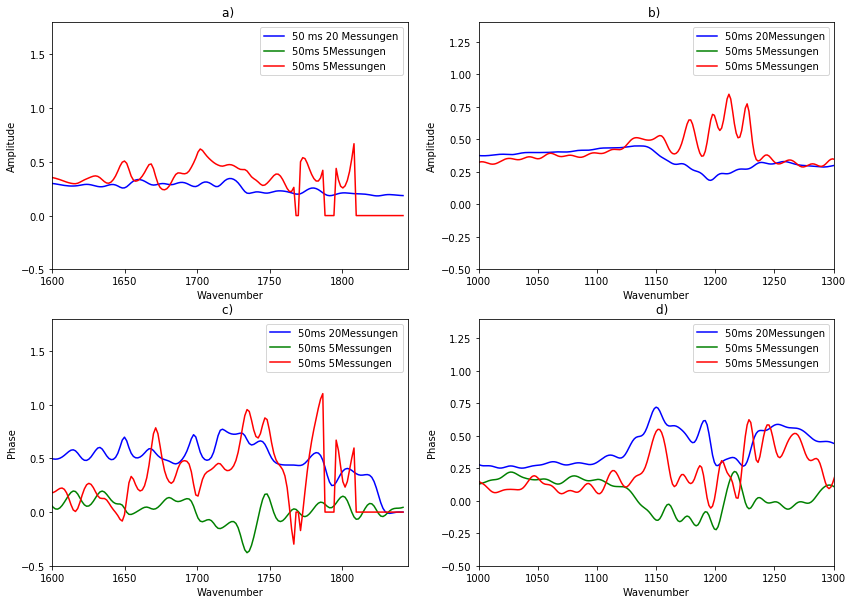

In [5]:
%matplotlib inline
plt.subplots_adjust(wspace=0.5,hspace=0.5)

plt.figure(figsize=(14,10)) 

plt.subplot(221) 
plt.plot(W5, A5, 'b-', label='50 ms 20 Messungen')
plt.plot(W6, A6, 'g-', label='50ms 5Messungen')
plt.plot(W7, A7, 'r-', label='50ms 5Messungen')
plt.title('a) ')
plt.axis([1600, 1845, -0.5, 1.8])
plt.legend()
plt.xlabel('Wavenumber')
plt.ylabel('Amplitude')

plt.subplot(222)
plt.plot(W5, A5, 'b-', label='50ms 20Messungen')
plt.plot(W6, A6, 'g-', label='50ms 5Messungen')
plt.plot(W7, A7, 'r-', label='50ms 5Messungen')
plt.title('b) ')
plt.axis([1000, 1300, -0.5, 1.4])
plt.legend()
plt.xlabel('Wavenumber')
plt.ylabel('Amplitude')

plt.subplot(223) 
plt.plot(W5, P5, 'b-', label='50ms 20Messungen')
plt.plot(W6, P6, 'g-', label='50ms 5Messungen')
plt.plot(W7, P7, 'r-', label='50ms 5Messungen')
plt.title('c) ')
plt.axis([1600, 1845, -0.5, 1.8])
plt.legend()
plt.xlabel('Wavenumber')
plt.ylabel('Phase')

plt.subplot(224)
plt.plot(W5, P5, 'b-', label='50ms 20Messungen')
plt.plot(W6, P6, 'g-', label='50ms 5Messungen')
plt.plot(W7, P7, 'r-', label='50ms 5Messungen')
plt.title('d) ', horizontalalignment='left')
plt.axis([1000, 1300, -0.5, 1.4])
plt.legend()
plt.xlabel('Wavenumber')
plt.ylabel('Phase')
plt.savefig("600px.pdf")

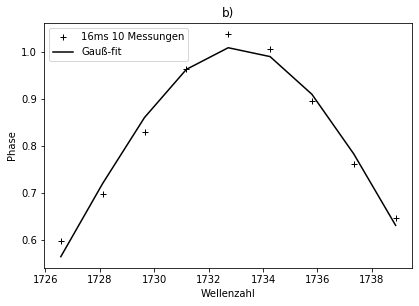

<Figure size 432x288 with 0 Axes>

In [6]:
def Gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
n=1123
m=1132
#n=1100
#m=1160
# weighted arithmetic mean (corrected - check the section below)
mean = sum(W4[n:m] * P4[n:m]) / sum(P4[n:m])
sigma = np.sqrt(sum(P4[n:m] * (W4[n:m] - mean)**2) / sum(P4[n:m]))


popt,pcov = curve_fit(Gauss, W4[n:m], P4[n:m], p0=[max(P4[n:m]), mean, sigma])
y = Gauss(W4[n:m], *popt)
#plt.plot(Wt, At, 'b+:', label='data')
f=plt.figure(figsize=(6.6, 4.5)) 
plt.plot(W4[n:m], P4[n:m], 'k+', label='16ms 10 Messungen')
plt.plot(W4[n:m], y, 'k-', label='Gauß-fit')
#plt.axis([1726,1740, 0.5,1.1])
plt.legend()
plt.title('b)')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()

plt.savefig('1730gaus4.pdf')
signal4=np.max(y)-np.min(y)
#f = plt.figure()
# plt.plot(range(10), range(10), "o")
#plt.show()

f.savefig("4gaus1730.pdf", bbox_inches='tight')

o=1100
p=1160
popt,pcov = curve_fit(Gauss, W4[n:m], P4[n:m], p0=[max(P4[n:m]), mean, sigma])
y = Gauss(W4[o:p], *popt)
N4=P4[o:p]-y
plt.plot(W4[o:p], N4, 'k-', label='Peak-Gauß')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()



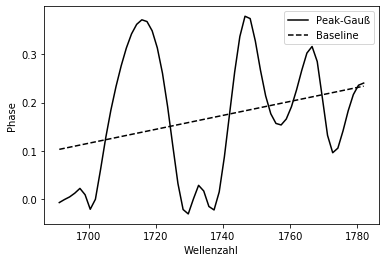

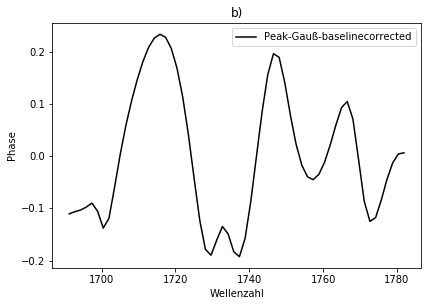

In [7]:
o=1100
p=1160
popt,pcov = curve_fit(Gauss, W4[n:m], P4[n:m], p0=[max(P4[n:m]), mean, sigma])
y = Gauss(W4[o:p], *popt)
N4=P4[o:p]-y

def lin(x, m, c):
    return m * x + c
    
#curve_fit(func, xdata, ydata, sigma=yerr)

popt,pcov = curve_fit(lin, W4[o:p], N4)
base_c = lin(W4[o:p], *popt)

plt.plot(W4[o:p], N4, 'k-', label='Peak-Gauß')
plt.plot(W4[o:p], base_c, 'k--', label='Baseline')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()

N4c=N4-base_c
f=plt.figure(figsize=(6.6, 4.5)) 
plt.plot(W4[o:p], N4c, 'k-', label='Peak-Gauß-baselinecorrected')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('b)')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show() 
f.savefig("4noise1730.pdf", bbox_inches='tight')
noise4=np.sqrt(np.sum(N4c**2))

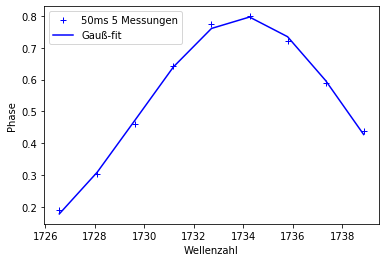

In [8]:
def Gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))


# weighted arithmetic mean (corrected - check the section below)
mean = sum(W1[n:m] * P1[n:m]) / sum(P1[n:m])
sigma = np.sqrt(sum(P1[n:m] * (W1[n:m] - mean)**2) / sum(P1[n:m]))


popt,pcov = curve_fit(Gauss, W1[n:m], P1[n:m], p0=[max(P1[n:m]), mean, sigma])
y = Gauss(W1[n:m], *popt)
f=plt.figure(figsize=(6.6, 4.5)) 
#plt.plot(Wt, At, 'b+:', label='data')
plt.plot(W1[n:m], P1[n:m], 'b+', label='50ms 5 Messungen')
plt.plot(W1[n:m], y, 'b-', label='Gauß-fit')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
f.savefig("1gaus1730.pdf", bbox_inches='tight')
signal1=np.max(y)-np.min(y)

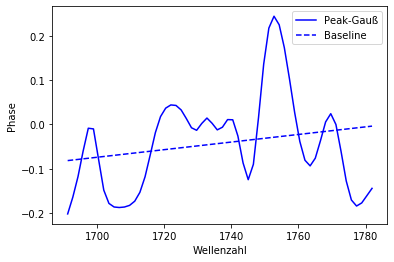

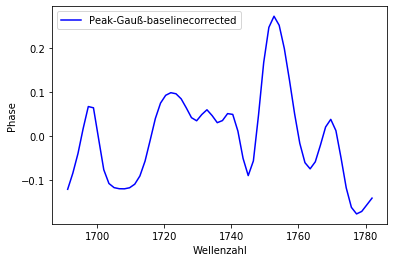

In [9]:
o=1100
p=1160
y = Gauss(W4[o:p], *popt)
N1=P1[o:p]-y
def lin(x, m, c):
    return m * x + c
    
#curve_fit(func, xdata, ydata, sigma=yerr)

popt,pcov = curve_fit(lin, W1[o:p], N1)
base_c = lin(W1[o:p], *popt)

plt.plot(W1[o:p], N1, 'b-', label='Peak-Gauß')
plt.plot(W1[o:p], base_c, 'b--', label='Baseline')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
N1c=N1-base_c
f=plt.figure(figsize=(6.6, 4.5)) 
plt.plot(W1[o:p], N1c, 'b-', label='Peak-Gauß-baselinecorrected')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
f.savefig("1noise1730.pdf", bbox_inches='tight')
noise1=np.sqrt(np.sum(N1c**2))

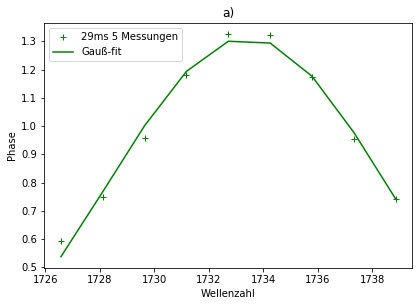

In [10]:
def Gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))


# weighted arithmetic mean (corrected - check the section below)
mean = sum(W2[n:m] * P2[n:m]) / sum(P2[n:m])
sigma = np.sqrt(sum(P2[n:m] * (W2[n:m] - mean)**2) / sum(P2[n:m]))


popt,pcov = curve_fit(Gauss, W2[n:m], P2[n:m], p0=[max(P2[n:m]), mean, sigma])
y = Gauss(W2[n:m], *popt)
#plt.plot(Wt, At, 'b+:', label='data')
f=plt.figure(figsize=(6.6, 4.5)) 
plt.plot(W2[n:m], P2[n:m], 'g+', label='29ms 5 Messungen')
plt.plot(W2[n:m], y, 'g-', label='Gauß-fit')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('a)')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
signal2=np.max(y)-np.min(y)

f.savefig("2gaus1730.pdf", bbox_inches='tight')


o=1100
p=1160
y = Gauss(W2[o:p], *popt)
N2=P2[o:p]-y
plt.plot(W2[o:p], N2, 'g-', label='Noise')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()

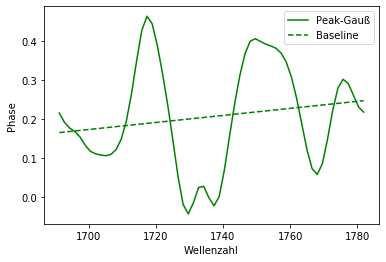

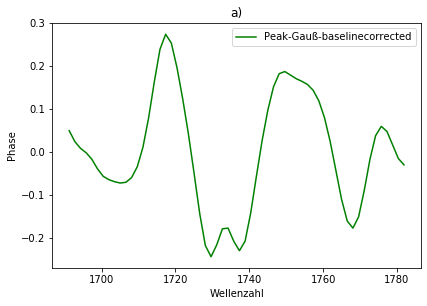

In [11]:
o=1100
p=1160
y = Gauss(W2[o:p], *popt)
N2=P2[o:p]-y
def lin(x, m, c):
    return m * x + c
    
#curve_fit(func, xdata, ydata, sigma=yerr)

popt,pcov = curve_fit(lin, W2[o:p], N2)
base_c = lin(W2[o:p], *popt)

plt.plot(W2[o:p], N2, 'g-', label='Peak-Gauß')
plt.plot(W2[o:p], base_c, 'g--', label='Baseline')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()

N2c=N2-base_c
f=plt.figure(figsize=(6.6, 4.5)) 
plt.plot(W2[o:p], N2c, 'g-', label='Peak-Gauß-baselinecorrected')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('a)')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
f.savefig("2noise1730.pdf", bbox_inches='tight')

noise2=np.sqrt(np.sum(N2c**2))

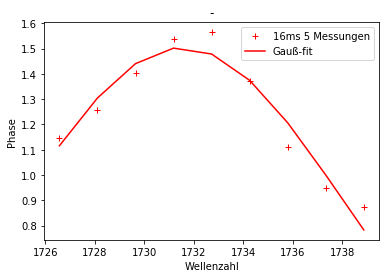

In [12]:
def Gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))


# weighted arithmetic mean (corrected - check the section below)
mean = sum(W3[n:m] * P3[n:m]) / sum(P3[n:m])
sigma = np.sqrt(sum(P3[n:m] * (W3[n:m] - mean)**2) / sum(P3[n:m]))


popt,pcov = curve_fit(Gauss, W3[n:m], P3[n:m], p0=[max(P3[n:m]), mean, sigma])
y = Gauss(W3[n:m], *popt)
#plt.plot(Wt, At, 'b+:', label='data')
plt.plot(W3[n:m], P3[n:m], 'r+', label='16ms 5 Messungen')
plt.plot(W3[n:m], y, 'r-', label='Gauß-fit')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('-')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
signal3=np.max(y)-np.min(y)

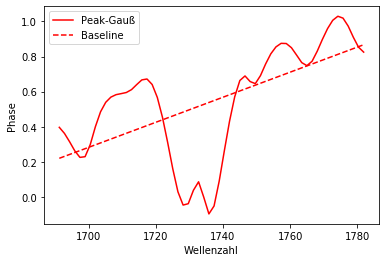

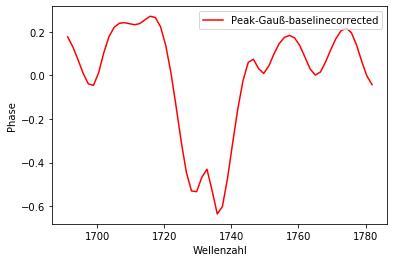

In [13]:
o=1100
p=1160
y = Gauss(W3[o:p], *popt)
N3=P3[o:p]-y

def lin(x, m, c):
    return m * x + c
    
#curve_fit(func, xdata, ydata, sigma=yerr)

popt,pcov = curve_fit(lin, W3[o:p], N3)
base_c = lin(W3[o:p], *popt)

plt.plot(W3[o:p], N3, 'r-', label='Peak-Gauß')
plt.plot(W3[o:p], base_c, 'r--', label='Baseline')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
N3c=N3-base_c
plt.plot(W3[o:p], N3c, 'r-', label='Peak-Gauß-baselinecorrected')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
noise3=np.sqrt(np.sum(N3c**2))

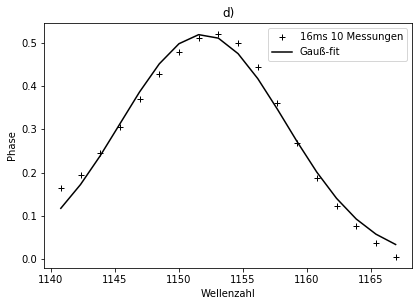

In [14]:
def Gauss(x, a, x0, sigma):
    
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
    

n=742
m=760
# weighted arithmetic mean (corrected - check the section below)
mean = sum(W4[n:m] * P4[n:m]) / sum(P4[n:m])
sigma = np.sqrt(sum(P4[n:m] * (W4[n:m] - mean)**2) / sum(P4[n:m]))


popt,pcov = curve_fit(Gauss, W4[n:m], P4[n:m], p0=[max(P4[n:m]), mean, sigma])
y = Gauss(W4[n:m], *popt)
f=plt.figure(figsize=(6.6, 4.5)) 
#plt.plot(Wt, At, 'b+:', label='data')
plt.plot(W4[n:m], P4[n:m], 'k+', label='16ms 10 Messungen')
plt.plot(W4[n:m], y, 'k-', label='Gauß-fit')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('d)')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
signal44=np.max(y)-np.min(y)
f.savefig("4gaus1150.pdf", bbox_inches='tight')

o=725
p=770
y = Gauss(W4[o:p], *popt)
N44=P4[o:p]-y
plt.plot(W4[o:p], N44, 'k-', label='Noise')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()

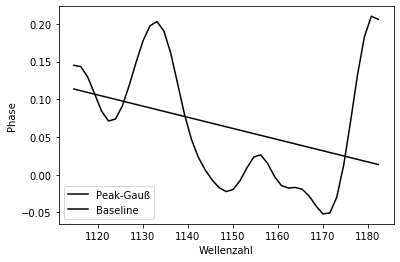

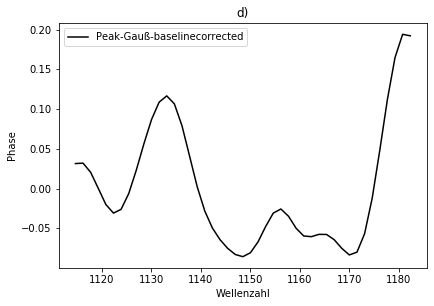

In [15]:
o=725
p=770
y = Gauss(W4[o:p], *popt)
N44=P4[o:p]-y
def lin(x, m, c):
    return m * x + c
    
#curve_fit(func, xdata, ydata, sigma=yerr)

popt,pcov = curve_fit(lin, W4[o:p], N44)
base_c = lin(W4[o:p], *popt)

plt.plot(W4[o:p], N44, 'k-', label='Peak-Gauß')
plt.plot(W4[o:p], base_c, 'k-', label='Baseline')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()

N44c=N44-base_c
f=plt.figure(figsize=(6.6, 4.5)) 
plt.plot(W4[o:p], N44c, 'k-', label='Peak-Gauß-baselinecorrected')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('d)')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
f.savefig("4noise1150.pdf", bbox_inches='tight')
noise44=np.sqrt(np.sum(N44c**2))

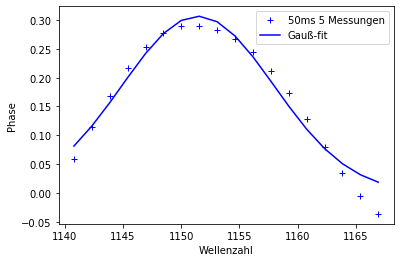

In [16]:
def Gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))
n=742
m=760


mean = sum(W1[n:m] * P1[n:m]) / sum(P1[n:m])
sigma = np.sqrt(sum(P1[n:m] * (W1[n:m] - mean)**2) / sum(P1[n:m]))


popt,pcov = curve_fit(Gauss, W1[n:m], P1[n:m], p0=[max(P1[n:m]), mean, sigma])
y = Gauss(W1[n:m], *popt)
f=plt.figure(figsize=(6.6, 4.5)) 
plt.plot(W1[n:m], P1[n:m], 'b+', label='50ms 5 Messungen')
plt.plot(W1[n:m], y, 'b-', label='Gauß-fit')
    
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
signal11=np.max(y)-np.min(y)

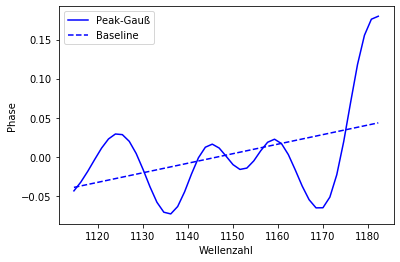

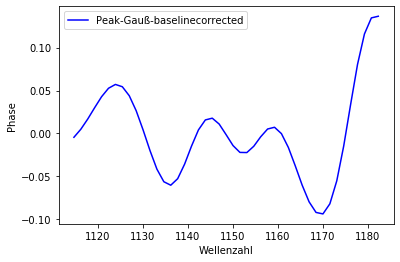

In [17]:
o=725
p=770
y = Gauss(W1[o:p], *popt)
N11=P1[o:p]-y
def lin(x, m, c):
    return m * x + c
    
#curve_fit(func, xdata, ydata, sigma=yerr)

popt,pcov = curve_fit(lin, W1[o:p], N11)
base_c = lin(W1[o:p], *popt)

plt.plot(W1[o:p], N11, 'b-', label='Peak-Gauß')
plt.plot(W1[o:p], base_c, 'b--', label='Baseline')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()

N11c=N11-base_c
f=plt.figure(figsize=(6.6, 4.5)) 
plt.plot(W1[o:p], N11c, 'b-', label='Peak-Gauß-baselinecorrected')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
noise11=np.sqrt(np.sum(N11c**2))

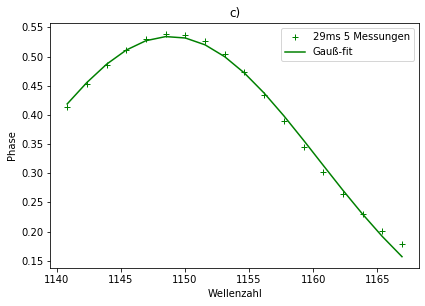

In [18]:
def Gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))


# weighted arithmetic mean (corrected - check the section below)
mean = sum(W2[n:m] * P2[n:m]) / sum(P2[n:m])
sigma = np.sqrt(sum(P2[n:m] * (W2[n:m] - mean)**2) / sum(P2[n:m]))


popt,pcov = curve_fit(Gauss, W2[n:m], P2[n:m], p0=[max(P2[n:m]), mean, sigma])
y = Gauss(W2[n:m], *popt)
f=plt.figure(figsize=(6.6, 4.5)) 
#plt.plot(Wt, At, 'b+:', label='data')
plt.plot(W2[n:m], P2[n:m], 'g+', label='29ms 5 Messungen')
plt.plot(W2[n:m], y, 'g-', label='Gauß-fit')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('c)')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
signal22=np.max(y)-np.min(y)
f.savefig("2gaus1150.pdf", bbox_inches='tight')

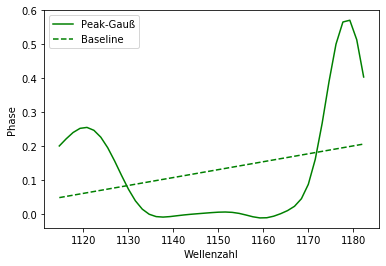

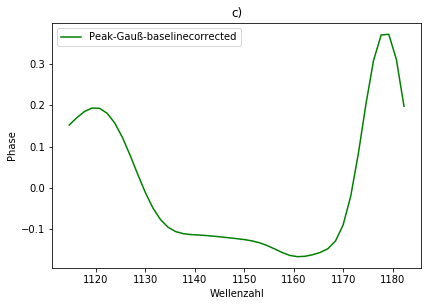

In [19]:
o=725
p=770
y = Gauss(W2[o:p], *popt)
N22=P2[o:p]-y
def lin(x, m, c):
    return m * x + c
    
#curve_fit(func, xdata, ydata, sigma=yerr)

popt,pcov = curve_fit(lin, W2[o:p], N22)
base_c = lin(W2[o:p], *popt)

plt.plot(W2[o:p], N22, 'g-', label='Peak-Gauß')
plt.plot(W2[o:p], base_c, 'g--', label='Baseline')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()

N22c=N22-base_c
f=plt.figure(figsize=(6.6, 4.5)) 
plt.plot(W2[o:p], N22c, 'g-', label='Peak-Gauß-baselinecorrected')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('c)')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
f.savefig("2noise1150.pdf", bbox_inches='tight')
noise22=np.sqrt(np.sum(N22c**2))

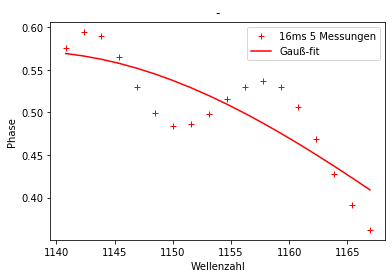

In [20]:
def Gauss(x, a, x0, sigma):
    return a * np.exp(-(x - x0)**2 / (2 * sigma**2))


# weighted arithmetic mean (corrected - check the section below)
mean = sum(W3[n:m] * P3[n:m]) / sum(P3[n:m])
sigma = np.sqrt(sum(P3[n:m] * (W3[n:m] - mean)**2) / sum(P3[n:m]))


popt,pcov = curve_fit(Gauss, W3[n:m], P3[n:m], p0=[max(P3[n:m]), mean, sigma])
y = Gauss(W3[n:m], *popt)
#plt.plot(Wt, At, 'b+:', label='data')
plt.plot(W3[n:m], P3[n:m], 'r+', label='16ms 5 Messungen')
plt.plot(W3[n:m], y, 'r-', label='Gauß-fit')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('-')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()

signal33=np.max(y)-np.min(y)

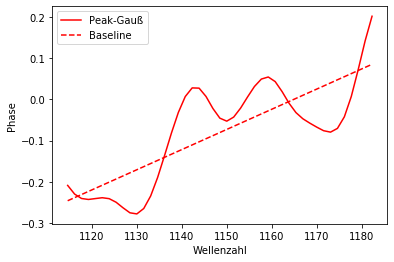

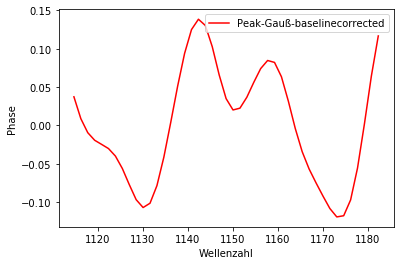

In [21]:
o=725
p=770
y = Gauss(W3[o:p], *popt)
N33=P3[o:p]-y
def lin(x, m, c):
    return m * x + c
    
#curve_fit(func, xdata, ydata, sigma=yerr)

popt,pcov = curve_fit(lin, W3[o:p], N33)
base_c = lin(W3[o:p], *popt)

plt.plot(W3[o:p], N33, 'r-', label='Peak-Gauß')
plt.plot(W3[o:p], base_c, 'r--', label='Baseline')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()
N33c=N33-base_c
plt.plot(W3[o:p], N33c, 'r-', label='Peak-Gauß-baselinecorrected')
    #plt.axis([0,1000, 0,4])
plt.legend()
plt.title('')
plt.xlabel('Wellenzahl')
plt.ylabel('Phase')
plt.show()



noise33=np.sqrt(np.sum(N33c**2))

In [22]:
print(noise1,noise11)
print(noise2,noise22)
print(noise3,noise33)
print(noise4,noise44)


0.8102671421318844 0.3560700030014475
1.042735707264085 1.108950334060766
1.9309676573765682 0.5009645308275777
0.9580216539818173 0.513710031897518


In [23]:
print(signal1/noise1,signal11/noise11)
print(signal2/noise2,signal22/noise22)
print(signal3/noise3,signal33/noise33)
print(signal4/noise4,signal44/noise44)

0.7632658825986178 0.8091550155964169
0.7315144900724743 0.34024324889942564
0.3723610025478844 0.31964048049345045
0.4638162102666689 0.9430760771396313


Bestes Signal zu Rausch Verhältnis an 1730  liegt bei der Integrationszeit von (1) 29 ms und Mittelung 5 Messungen und erhält durchschnittliche werte für den Peak an 1150. Die Messung von 16ms bei gleicher Mittelung liefert hier nahezu gleich gute werte, kann jedoch 2. Peak nicht auflösen. 

Bei (2) 16 ms und 10 Messungen wird der peak an 1150 am besten aufgelöst. aber das Signal zu rausch verhältnis an 1730 ist mit abstand das geringste . Beide Messungen (1) und (2) benötigen 2 Minuten gesammte Messzeit. 

Würde (1) über die doppelte menge an Messungen gemittelt werden, würde man auch für den 2. Peak ein noch höheres Verhältnis erhalten.. jedoch die Messzeit verdoppeln. Als bestes Signal/Rausch in bezug auf die Messzeit wird somit Messung (2) genommen. jedoch können je nach priorität des 2. Peaks zusätzliche Mittelungen vorgenommen werden.

## 📌 Summary

- This notebook evaluates how spectral quality and resolution depend on interferogram length and integration settings.
- The visibility of the 1730 cm⁻¹ PMMA peak was used as a key metric.
- Gaussian fits and contrast profiles helped identify optimal measurement strategies.